MDS DATATHON 2025 - Tsunami Classification

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from sklearn.model_selection import cross_validate

In [ ]:
df = pd.read_csv('train.csv')
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,6.9,0,6,732,117,0.0,0.0,28.0,-4.022,101.776,2001,1,0
1,6.8,0,5,711,64,0.0,0.0,33.0,6.631,126.899,2001,1,0
2,7.2,4,4,838,443,0.0,17.0,19.0,2.433,93.210,2012,1,0
3,6.5,0,6,650,700,0.0,47.4,43.0,51.148,157.522,2006,8,0
4,6.6,8,8,831,782,0.0,16.7,12.0,37.535,138.446,2007,7,0


In [3]:
df.describe(include='all')

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,547.00000,547.000000,547.000000,547.000000,547.000000,547.000000,547.000000,547.000000,547.000000,547.000000,547.000000,547.000000,547.000000
mean,6.94691,4.316271,5.983547,873.877514,227.928702,1.273496,25.911865,72.136806,3.575073,53.158692,2012.374771,6.691042,0.389397
std,0.46434,3.207216,1.461879,331.264728,248.404050,2.206279,25.558074,135.393307,27.006892,117.128126,6.145395,3.606259,0.488060
min,6.50000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.60000,0.000000,5.000000,691.000000,0.000000,0.000000,14.750000,13.000000,-13.965800,-71.554250,2007.000000,3.000000,0.000000
50%,6.80000,5.000000,6.000000,755.000000,139.000000,0.000000,20.700000,25.000000,-2.405000,108.174000,2013.000000,7.000000,0.000000
75%,7.10000,7.000000,7.000000,915.500000,444.000000,1.728000,30.100000,45.000000,24.404500,147.818000,2018.000000,10.000000,1.000000
max,9.10000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,67.631000,179.544000,2022.000000,12.000000,1.000000


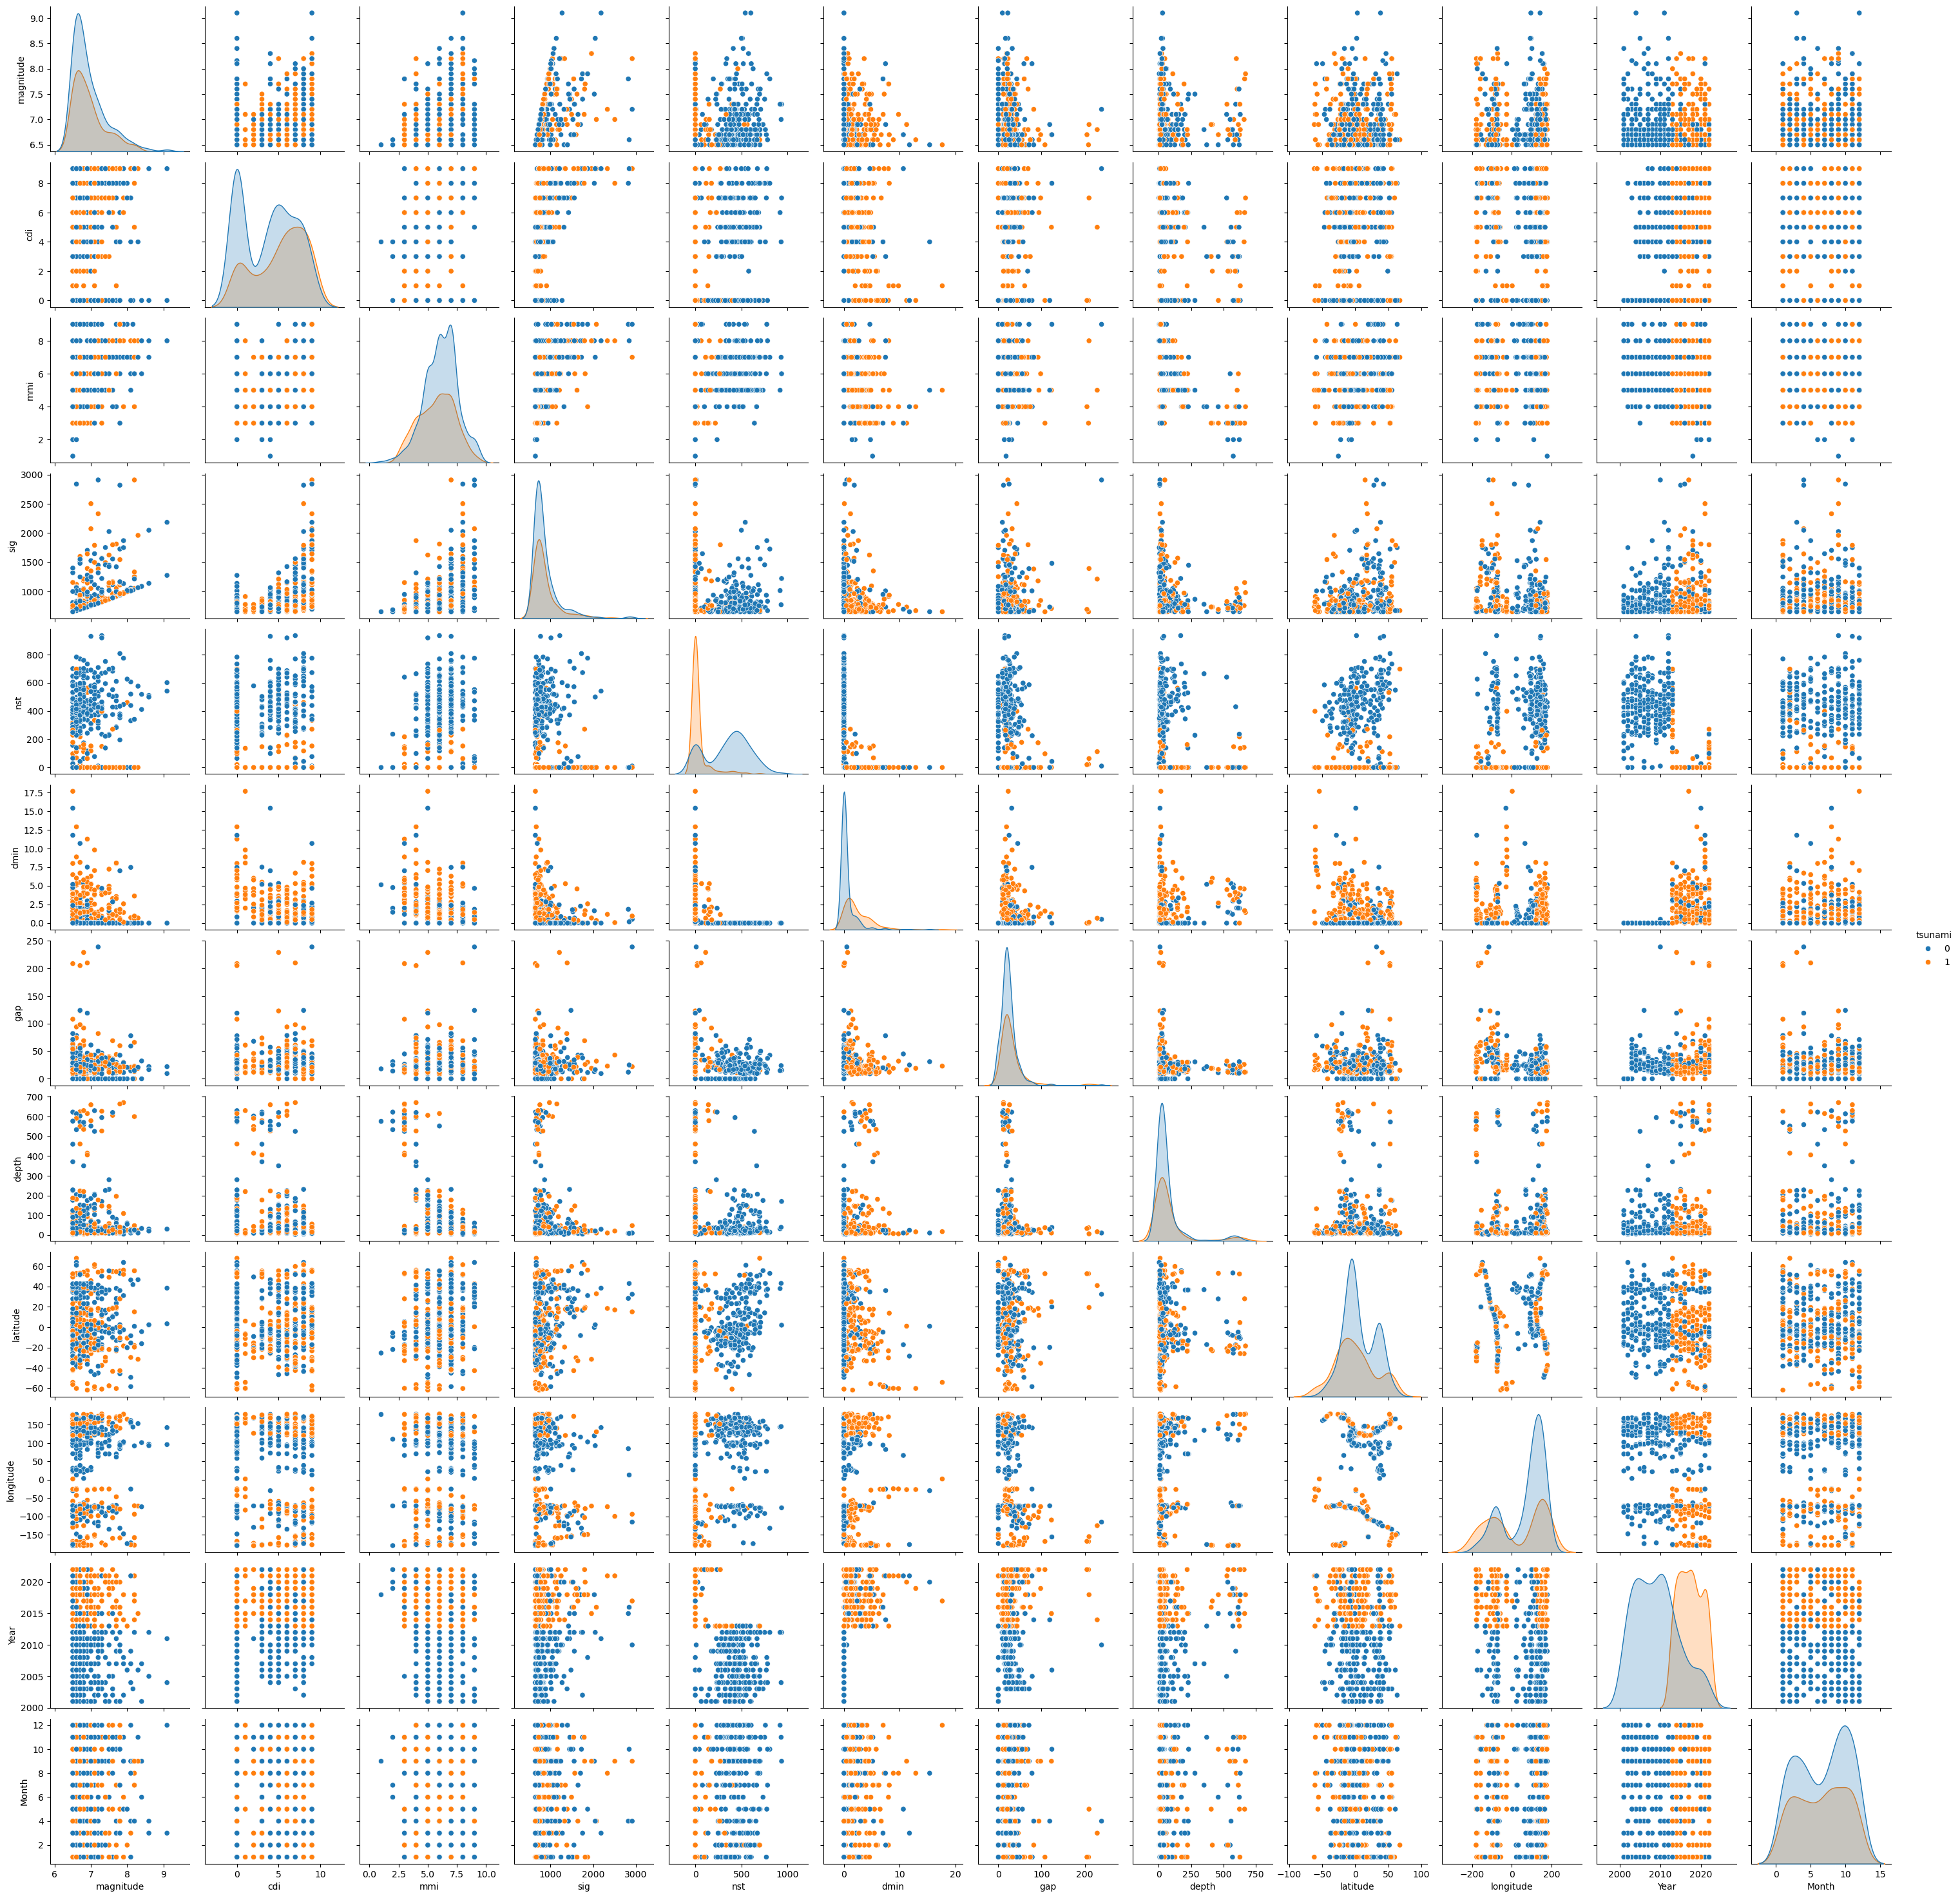

In [4]:
sns.pairplot(df, hue='tsunami')

<Axes: >

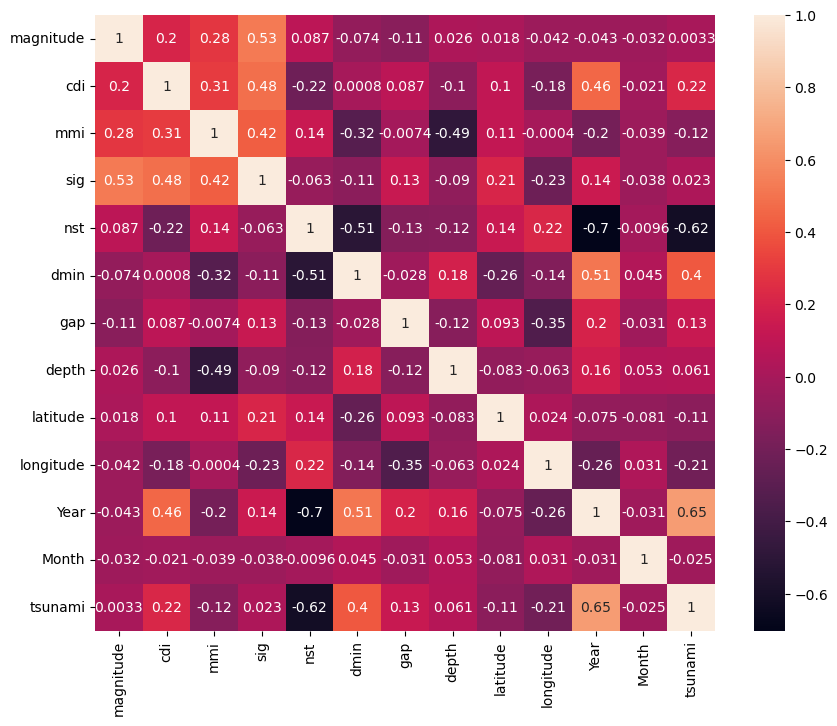

In [6]:
plt.figure(figsize = (10,8))
corr = df.corr()
sns.heatmap(corr, annot=True)

A few correlated features are visible, such as year and nst, but these should not be problematic as we dont expect year to be used as a predictor.

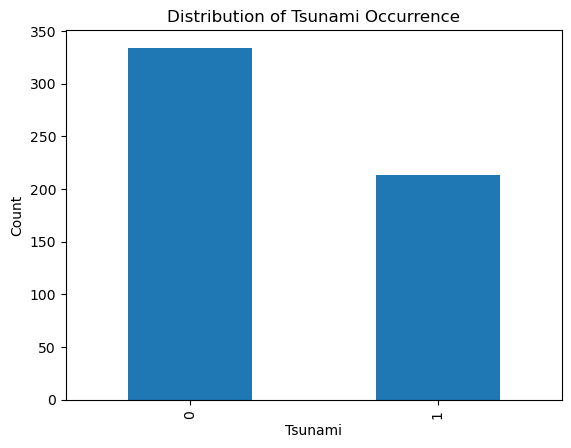

In [8]:
df['tsunami'].value_counts().plot(kind='bar')
plt.title('Distribution of Tsunami Occurrence')
plt.xlabel('Tsunami')
plt.ylabel('Count')
plt.show()

In [10]:
df['tsunami'].value_counts()

tsunami
0    334
1    213
Name: count, dtype: int64

There is a class imbalance in the target variable, indicating that tsunami events are much rarer than non-tsunami events. This will need to be addressed during model training to avoid biased predictions.

In [76]:
X = df.drop('tsunami', axis=1)
y = df['tsunami']

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
dummy_scaler = StandardScaler()
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_pipe = make_pipeline(dummy_scaler, dummy_clf)
dummy_pipe.fit(X, y)



,steps,"[('standardscaler', ...), ('dummyclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,strategy,'most_frequent'
,random_state,None
,constant,None


In [78]:
dummy_scores = cross_validate(dummy_pipe, X, y, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'])
pd.DataFrame(dummy_scores).mean()

/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

fit_time          0.002875
score_time        0.004252
test_accuracy     0.610609
test_precision    0.000000
test_recall       0.000000
test_f1           0.000000
dtype: float64

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


Running a naive test classifier to establish well performing models before hyperparameter tuning

In [ ]:
models = {
    'logistic': LogisticRegression(),
    'random_forest': RandomForestClassifier(),
    'gradientboost': GradientBoostingClassifier(),
    'adaboost': AdaBoostClassifier(),
    'xgboost': XGBClassifier(),
    'lightgbm': LGBMClassifier(),
    'svm': SVC()
}

In [81]:
results_dict = {}
def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

In [82]:
results_dict["dummy"] = mean_std_cross_val_scores(
    dummy_pipe, X, y, cv=5, return_train_score=True
)


In [ ]:
for name, model in models.items():
    model_pipe = make_pipeline(scaler, model)
    ser = mean_std_cross_val_scores(model_pipe, X, y, cv=5,return_train_score=True) 
    results_dict[name] = ser

[LightGBM] [Info] Number of positive: 170, number of negative: 267
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 783
[LightGBM] [Info] Number of data points in the train set: 437, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389016 -> initscore=-0.451450
[LightGBM] [Info] Start training from score -0.451450
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/arafat/miniforge3/envs/class/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [84]:
cv_df = pd.DataFrame(results_dict).T
cv_df

,fit_time,score_time,test_score,train_score
dummy,0.006 (+/- 0.003),0.001 (+/- 0.001),0.611 (+/- 0.004),0.611 (+/- 0.001)
logistic,0.005 (+/- 0.006),0.001 (+/- 0.000),0.839 (+/- 0.061),0.849 (+/- 0.019)
random_forest,0.055 (+/- 0.004),0.002 (+/- 0.000),0.899 (+/- 0.032),1.000 (+/- 0.000)
gradientboost,0.066 (+/- 0.001),0.001 (+/- 0.000),0.920 (+/- 0.033),0.998 (+/- 0.000)
adaboost,0.032 (+/- 0.002),0.002 (+/- 0.000),0.923 (+/- 0.026),0.954 (+/- 0.005)
xgboost,0.104 (+/- 0.013),0.001 (+/- 0.000),0.910 (+/- 0.028),1.000 (+/- 0.000)
lightgbm,0.176 (+/- 0.008),0.002 (+/- 0.000),0.907 (+/- 0.027),1.000 (+/- 0.000)
svm,0.004 (+/- 0.001),0.001 (+/- 0.000),0.834 (+/- 0.059),0.888 (+/- 0.008)


In [96]:
from sklearn.model_selection import RandomizedSearchCV
scaler = StandardScaler()

In [51]:
from scipy.stats import randint, loguniform

In [115]:
param_dist = {
    # AdaBoost hyperparameters
    "adaboostclassifier__n_estimators": randint(50, 800),
    "adaboostclassifier__learning_rate": loguniform(1e-3, 1.0),

    # DecisionTree hyperparameters (the base estimator)
    "adaboostclassifier__estimator__max_depth": randint(1, 8),
    "adaboostclassifier__estimator__min_samples_split": randint(2, 20),
    "adaboostclassifier__estimator__min_samples_leaf": randint(1, 20),
    "adaboostclassifier__estimator__max_features": ["sqrt", "log2", None]
}

In [116]:
ada_pipe = make_pipeline(scaler, AdaBoostClassifier(estimator= DecisionTreeClassifier()))

In [121]:
grid = RandomizedSearchCV(ada_pipe, param_distributions=param_dist, n_iter=50, scoring='accuracy', cv=5, return_train_score=True, random_state=42)

In [122]:
grid.fit(X, y)

,estimator,Pipeline(step...assifier()))])
,param_distributions,"{'adaboostclassifier__estimator__max_depth': <scipy.stats....t 0x14f9b0440>, 'adaboostclassifier__estimator__max_features': ['sqrt', 'log2', ...], 'adaboostclassifier__estimator__min_samples_leaf': <scipy.stats....t 0x14f9b2570>, 'adaboostclassifier__estimator__min_samples_split': <scipy.stats....t 0x14f9b26c0>, ...}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [123]:
grid.best_score_

np.float64(0.9268557130942453)

In [124]:
testing_data = pd.read_csv('test.csv')
testing_data.head()

,id,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month
0,0,6.9,2,3,733,0,4.051,9.0,596.400,-19.7819,-178.2440,2016,9
1,1,6.5,7,8,1297,0,2.360,15.0,29.000,-22.6784,25.1558,2017,4
2,2,7.2,7,7,803,494,0.000,20.4,120.000,-15.5950,167.6800,2007,8
3,3,6.5,6,6,654,0,1.640,21.0,36.000,-10.3506,161.3350,2017,1
4,4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.2780,2022,11


In [126]:
id = testing_data['id']
predictions = grid.predict(testing_data.drop('id', axis=1))

In [127]:
submission = pd.DataFrame({
    'id': id,
    'tsunami': predictions
})

submission.to_csv('submission.csv', index=False)
submission.head()

,id,tsunami
0,0,1
1,1,0
2,2,0
3,3,1
4,4,1
